# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](https://compsci682-fa19.github.io/assignments2019/assignment1) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [29]:
### IF YOU ARE USING COLAB, UNCOMMENT AND RUN THIS BLOCK FIRST ###

# # Mount google drive to allow access to your files
# from google.colab import drive
# drive.mount('/content/drive')
# drive_folder = '/content/drive/MyDrive'
# # Ajust this line to be the assignment1 folder in your google drive
# notebook_folder = drive_folder + '/cs682/assignment1'
# %cd {notebook_folder}

In [30]:

from __future__ import print_function
import random
import numpy as np
from cs682.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [31]:
from cs682.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs682/datasets/cifar-10-batches-py'

    # Don't forget to run get_datasets.sh, or this will throw an error
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

Clear previously loaded data.


## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your interests.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [32]:
from cs682.features import *

num_color_bins = 10 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train SVM on features
Using the multiclass SVM code developed earlier in the assignment, train SVMs on top of the features extracted above; this should achieve better results than training SVMs directly on top of raw pixels.

In [33]:
# Use the validation set to tune the learning rate and regularization strength

from cs682.classifiers.linear_classifier import LinearSVM

results = {}
best_val = -1
best_svm = None

################################################################################
# 1TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained classifer in best_svm. You might also want to play          #
# with different numbers of bins in the color histogram. If you are careful    #
# you should be able to get accuracy of near 0.44 on the validation set.       #
################################################################################

# Using discrete values for learning rates and regularization strengths
# Note to self: Upon examining the results, I realised that 1e-9 and 1e-7 are too low for learning rate, so removing them from the learning rates list
# learning_rates = [1e-9, 1e-7, 1e-5, 1e-3]
learning_rates = [1e-5, 1e-3]
regularization_strengths = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
# After success in neural nets, I will play with num iter as well
num_iter_choices = [1500, 2000, 3000]

import itertools
total = len(list(itertools.product(learning_rates, regularization_strengths, num_iter_choices)))
counter = 1

best_tup = None
for learning_rate in learning_rates:
    for regularization_strength in regularization_strengths:
        for num_iters in num_iter_choices:
            svm = LinearSVM()
            loss_hist, grad_hist = svm.train(X_train_feats, y_train, learning_rate=learning_rate, reg=regularization_strength, num_iters=num_iters)
            
            # Training accuracy
            y_train_pred = svm.predict(X_train_feats)
            training_accuracy = np.mean(y_train == y_train_pred)
            
            # Validation accuracy
            y_val_pred = svm.predict(X_val_feats)
            validation_accuracy = np.mean(y_val == y_val_pred)
            
            results[(learning_rate, regularization_strength, num_iters)] = (training_accuracy, validation_accuracy)
            
            if validation_accuracy > best_val:
                best_val = validation_accuracy
                best_svm = svm
                best_tup = (learning_rate, regularization_strength, num_iters)
            
            # Just for monitoring progress
            print('Iteration: {}/{}: Validation accuracy: {} with learning rate: {}, regularization: {}, num_iters: {}'.format(counter, total, validation_accuracy, learning_rate, regularization_strength, num_iters))
            counter += 1

################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Commenting out the below code as it is not needed
## Print out results.
# for lr, reg, num_iters in sorted(results):
#     train_accuracy, val_accuracy = results[(lr, reg, num_iters)]
#     print('lr %e reg %e num_iter %d train accuracy: %f val accuracy: %f' % (
#                 lr, reg, num_iters, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print('Best tuple: ', best_tup)

Iteration: 1/54: Validation accuracy: 0.407 with learning rate: 1e-05, regularization: 0.01, num_iters: 1500
Iteration: 2/54: Validation accuracy: 0.403 with learning rate: 1e-05, regularization: 0.01, num_iters: 2000
Iteration: 3/54: Validation accuracy: 0.415 with learning rate: 1e-05, regularization: 0.01, num_iters: 3000
Iteration: 4/54: Validation accuracy: 0.407 with learning rate: 1e-05, regularization: 0.05, num_iters: 1500
Iteration: 5/54: Validation accuracy: 0.426 with learning rate: 1e-05, regularization: 0.05, num_iters: 2000
Iteration: 6/54: Validation accuracy: 0.419 with learning rate: 1e-05, regularization: 0.05, num_iters: 3000
Iteration: 7/54: Validation accuracy: 0.405 with learning rate: 1e-05, regularization: 0.1, num_iters: 1500
Iteration: 8/54: Validation accuracy: 0.406 with learning rate: 1e-05, regularization: 0.1, num_iters: 2000
Iteration: 9/54: Validation accuracy: 0.417 with learning rate: 1e-05, regularization: 0.1, num_iters: 3000
Iteration: 10/54: Vali

### Best configuration and results
best validation accuracy achieved during cross-validation: 0.498000  
Best tuple:  (0.001, 0.05, 3000)

In [34]:
# Evaluate your trained SVM on the test set
y_test_pred = best_svm.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.486


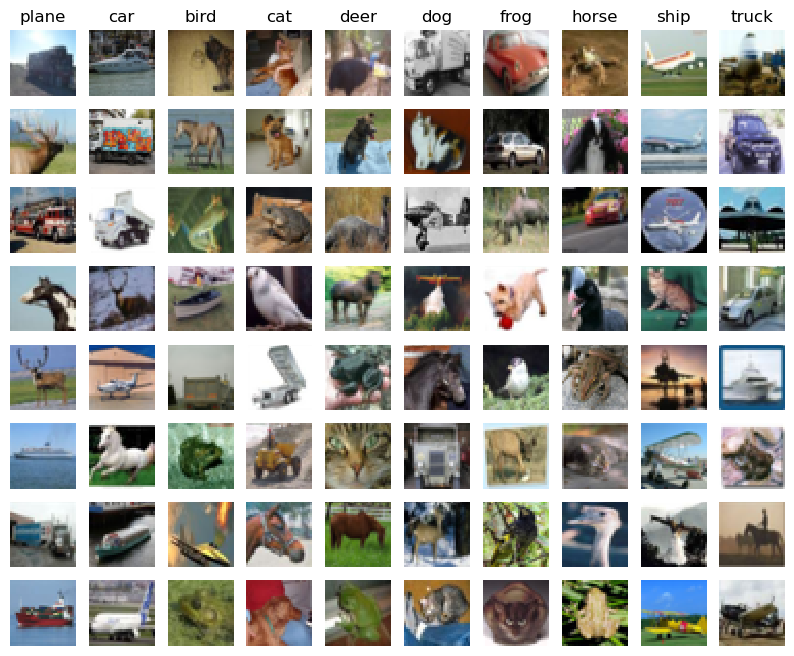

In [35]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?

Yes, these misclassifications do make sense. For example, the first column shows images that our system labeled as "plane" but whose true label is something other than "plane. The images are of similar shape and color to planes, so it makes sense that the classifier would misclassify them as planes. Background similarity is also a factor in misclassification, for eg - the sky and sea in plane and ship respectively can be similar in color and texture.

HOG captures the textures well but struggles with the intra-class variances. Color histogram captures the color information well but struggles with the texture information. Combining both should help in improving the classification accuracy.

## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [36]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 155)
(49000, 154)


In [37]:
from cs682.classifiers.neural_net import TwoLayerNet

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# 2TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
# Your code

learning_rates = [1e-1, 1e-2, 1e-3, 2e-3]
regularization_strengths = [2e-7, 1e-7, 1e-6, 1e-5]
hidden_sizes = [80, 100, 150, 200]
number_iters = [3000, 5000]

compute_logs = {}

best_val_acc = -1
best_tup = None

import itertools
total = len(list(itertools.product(hidden_sizes, regularization_strengths, learning_rates, number_iters)))
counter = 1


# Will write a pretty naive loop to find best hyperparameters
for hs in hidden_sizes:
    for reg_strength in regularization_strengths:
        for learning_rate in learning_rates:
            for num_iters in number_iters:
                net = TwoLayerNet(input_dim, hs, num_classes)
                stats = net.train(X_train_feats, y_train, X_val_feats, y_val,
                    num_iters=num_iters, batch_size=200,
                    learning_rate=learning_rate, learning_rate_decay=0.95,
                    reg=reg_strength, verbose=False)

                # make predictions on the training and validation sets
                y_train_pred = net.predict(X_train_feats)
                y_val_pred = net.predict(X_val_feats)

                # compute the accuracy on the training and validation sets
                train_acc = np.mean(y_train_pred == y_train)
                val_acc = np.mean(y_val_pred == y_val)

                compute_logs[(hs, reg_strength, learning_rate, num_iters)] = (train_acc, val_acc)
                print(f'Iteration: {counter}/{total}: Validation accuracy: {val_acc} with hidden size: {hs}, learning rate: {learning_rate}, regularization: {reg_strength} and num_iters: {num_iters}')
                counter += 1

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_net = net
                    best_tup = (hs, reg_strength, learning_rate, num_iters)

################################################################################
#                              END OF YOUR CODE                                #
################################################################################

Iteration: 1/128: Validation accuracy: 0.541 with hidden size: 80, learning rate: 0.1, regularization: 2e-07 and num_iters: 3000
Iteration: 2/128: Validation accuracy: 0.565 with hidden size: 80, learning rate: 0.1, regularization: 2e-07 and num_iters: 5000
Iteration: 3/128: Validation accuracy: 0.229 with hidden size: 80, learning rate: 0.01, regularization: 2e-07 and num_iters: 3000
Iteration: 4/128: Validation accuracy: 0.303 with hidden size: 80, learning rate: 0.01, regularization: 2e-07 and num_iters: 5000
Iteration: 5/128: Validation accuracy: 0.079 with hidden size: 80, learning rate: 0.001, regularization: 2e-07 and num_iters: 3000
Iteration: 6/128: Validation accuracy: 0.078 with hidden size: 80, learning rate: 0.001, regularization: 2e-07 and num_iters: 5000
Iteration: 7/128: Validation accuracy: 0.078 with hidden size: 80, learning rate: 0.002, regularization: 2e-07 and num_iters: 3000
Iteration: 8/128: Validation accuracy: 0.078 with hidden size: 80, learning rate: 0.002, 

In [38]:
# Print out results.
for hs, reg_strength, learning_rate, num_iters in sorted(compute_logs):
    train_accuracy, val_accuracy = compute_logs[(hs, reg_strength, learning_rate, num_iters)]
    print('hs %e reg %f lr %f num_iter %d train accuracy: %f val accuracy: %f' % (
                hs, reg_strength, learning_rate, num_iters, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val_acc)
print('Best tuple: ', best_tup)

hs 8.000000e+01 reg 0.000000 lr 0.001000 num_iter 3000 train accuracy: 0.100449 val accuracy: 0.078000
hs 8.000000e+01 reg 0.000000 lr 0.001000 num_iter 5000 train accuracy: 0.099959 val accuracy: 0.102000
hs 8.000000e+01 reg 0.000000 lr 0.002000 num_iter 3000 train accuracy: 0.100429 val accuracy: 0.079000
hs 8.000000e+01 reg 0.000000 lr 0.002000 num_iter 5000 train accuracy: 0.100449 val accuracy: 0.078000
hs 8.000000e+01 reg 0.000000 lr 0.010000 num_iter 3000 train accuracy: 0.228653 val accuracy: 0.223000
hs 8.000000e+01 reg 0.000000 lr 0.010000 num_iter 5000 train accuracy: 0.291551 val accuracy: 0.294000
hs 8.000000e+01 reg 0.000000 lr 0.100000 num_iter 3000 train accuracy: 0.572551 val accuracy: 0.559000
hs 8.000000e+01 reg 0.000000 lr 0.100000 num_iter 5000 train accuracy: 0.600612 val accuracy: 0.573000
hs 8.000000e+01 reg 0.000000 lr 0.001000 num_iter 3000 train accuracy: 0.100429 val accuracy: 0.079000
hs 8.000000e+01 reg 0.000000 lr 0.001000 num_iter 5000 train accuracy: 0.

In [39]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 55% accuracy.

test_acc = (best_net.predict(X_test_feats) == y_test).mean()
print(test_acc)

0.55
